# 🏥 Lab 0: Data Exploration & Preprocessing
**BINF 4002 – Machine Learning for Health**

---
## Learning Objectives
1. Load and inspect a real-world clinical dataset
2. Perform exploratory data analysis (EDA)
3. Identify and handle missing values correctly
4. Encode and scale features — and understand *why* each step matters
5. Split data properly to avoid data leakage
6. Understand what can go wrong at each step, using concrete clinical examples
7. Save cleaned data for all subsequent model labs

## Dataset
**Breast Cancer Wisconsin** (`sklearn.datasets`) — 569 samples, 30 numeric features
derived from cell-nucleus images; binary outcome: malignant (0) vs. benign (1).

> ⚠️ **Reproducibility note**: set a random seed everywhere. Results that cannot be
> reproduced cannot be trusted in clinical research.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import f_classif
import pickle, warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette("Set2")

raw = load_breast_cancer()
df  = pd.DataFrame(raw.data, columns=raw.feature_names)
df['target']    = raw.target           # 0 = malignant, 1 = benign
df['diagnosis'] = df['target'].map({0:'Malignant', 1:'Benign'})

print(f"Shape: {df.shape}")
print(f"Classes:\n{df['diagnosis'].value_counts()}")
df.head(3)


Shape: (569, 32)
Classes:
diagnosis
Benign       357
Malignant    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,diagnosis
0,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,Malignant
1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,Malignant
2,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,Malignant


---
## Part 1 — First Look at the Data

Before running any model, answer: *What is our data? What is our problem? What are we predicting? For whom? With what features?*
These questions seem obvious, but skipping them is the root cause of many published ML failures in healthcare.

For now, take a moment to look up information about the source of this data (in the real world, you might need to ask colleagues about the data, or work with clinical or biology collaborators to understand how and why the data were generated).

**Add a text cell below summarizing some of the essential aspects of the data. What kinds of problems could this data help solve? In addition, describe a plan for how you might do exploratory data analysis on these data (e.g., to investigate the data to better understand it).**

---
### ✅ Solution — Data Summary

**About the data:** The Breast Cancer Wisconsin dataset contains measurements from digitized images of fine needle aspirates (FNA) of breast masses. Each row represents a tumor sample, and the 30 numeric features describe characteristics of cell nuclei visible in the image (e.g., radius, texture, smoothness, symmetry). The binary target indicates whether the mass is malignant (cancerous) or benign.

**Who generates this data:** Pathologists collect tissue via FNA, and the images are analyzed (often with automated image processing). Variability can arise from differences in imaging equipment, staining protocols, and digitization procedures across hospitals.

**What problems could this help solve:** This data supports automated screening or triage for breast cancer diagnosis — potentially flagging suspicious masses for further biopsy or specialist review.

**EDA plan:** We should examine class balance, feature distributions (looking for skewness, outliers, and bimodality), correlations between features (especially geometrically related ones like radius/perimeter/area), and whether any features clearly separate the classes.


Below, we do show some basic aspects of the data. Feel free to extend this with your own data anlaysis code!

In [2]:
print("Feature summary:")
df.drop(columns=['target','diagnosis']).describe().T[['mean','std','min','max']].round(3)

Feature summary:


,mean,std,min,max
mean radius,14.127,3.524,6.981,28.110
mean texture,19.290,4.301,9.710,39.280
mean perimeter,91.969,24.299,43.790,188.500
mean area,654.889,351.914,143.500,2501.000
mean smoothness,0.096,0.014,0.053,0.163
mean compactness,0.104,0.053,0.019,0.345
mean concavity,0.089,0.080,0.000,0.427
mean concave points,0.049,0.039,0.000,0.201
mean symmetry,0.181,0.027,0.106,0.304
mean fractal dimension,0.063,0.007,0.050,0.097


### 🤔 Reflection 1.1 — Clinical Context

Before looking at the features more carefully, answer these questions:

1. These features are derived from cell-nucleus images. Who collects this data in a hospital?
   Would every hospital collect it in the same way? What problems might arise if a model
   trained at one hospital is deployed at another?

2. The dataset has 357 benign and 212 malignant cases (~63% benign).
   If you built a model that **always predicts "benign"**, what would its accuracy be?
   Is that a useful model? What does this tell you about using accuracy as your primary metric?

3. We have 569 samples and 30 features. Is this a big dataset for healthcare? Compare to
   what you might have in a clinical trial vs. an EHR system. How does dataset size affect
   what models are appropriate?


---
### ✅ Solution — Reflection 1.1

**1.** Pathologists and lab technicians collect FNA samples and digitize the images. Different hospitals may use different imaging equipment, staining protocols, magnification levels, and image processing software. A model trained at one hospital could fail at another due to these differences — this is called **domain shift** or **distribution shift**. For example, if Hospital A's scanner produces systematically larger cell measurements than Hospital B's, the model's learned thresholds would be miscalibrated.

**2.** A model that always predicts "benign" would have accuracy = 357/569 ≈ **62.7%**. This is *not* a useful model — it would miss every single malignant case (sensitivity = 0%). This demonstrates that **accuracy is a misleading metric when classes are imbalanced**. A model that never detects cancer is clinically useless despite appearing to be "correct" 63% of the time. Metrics like sensitivity, specificity, PPV, and AUC are far more informative.

**3.** 569 samples is small-to-moderate for healthcare ML. A typical clinical trial might have 100–1,000 patients; an EHR-based study could have 10,000–10,000,000. With only 569 samples and 30 features, we are in a regime where simpler models (logistic regression, small trees) are likely to outperform complex ones (deep neural networks), because complex models can easily overfit. The ratio of samples to features (~19:1) is reasonable but not large — we need to be cautious about overfitting.


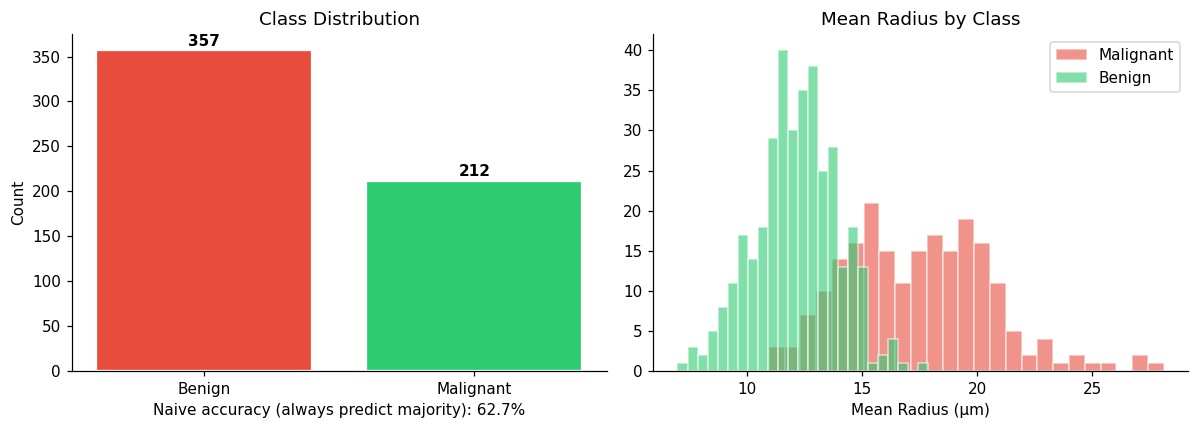

In [3]:
# Class distribution
fig, axes = plt.subplots(1, 2, figsize=(11,4))

counts = df['diagnosis'].value_counts()
axes[0].bar(counts.index, counts.values,
            color=['#e74c3c','#2ecc71'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Count')
for i,v in enumerate(counts.values):
    axes[0].text(i, v+5, str(v), ha='center', fontweight='bold')

# Naive-classifier baseline
naive_acc = counts.max() / counts.sum()
axes[0].set_xlabel(f'Naive accuracy (always predict majority): {naive_acc:.1%}')

# Feature: mean radius by class
for label, color, name in zip([0,1],['#e74c3c','#2ecc71'],['Malignant','Benign']):
    axes[1].hist(df[df['target']==label]['mean radius'], bins=25,
                 alpha=0.6, label=name, color=color, edgecolor='white')
axes[1].set_title('Mean Radius by Class')
axes[1].set_xlabel('Mean Radius (µm)')
axes[1].legend()

plt.tight_layout(); plt.show()


---
## Part 2 — Feature Distributions and Outliers

Real clinical data is messy. Features can have extreme outliers, skewed distributions, or
values that are impossible given the measurement context.


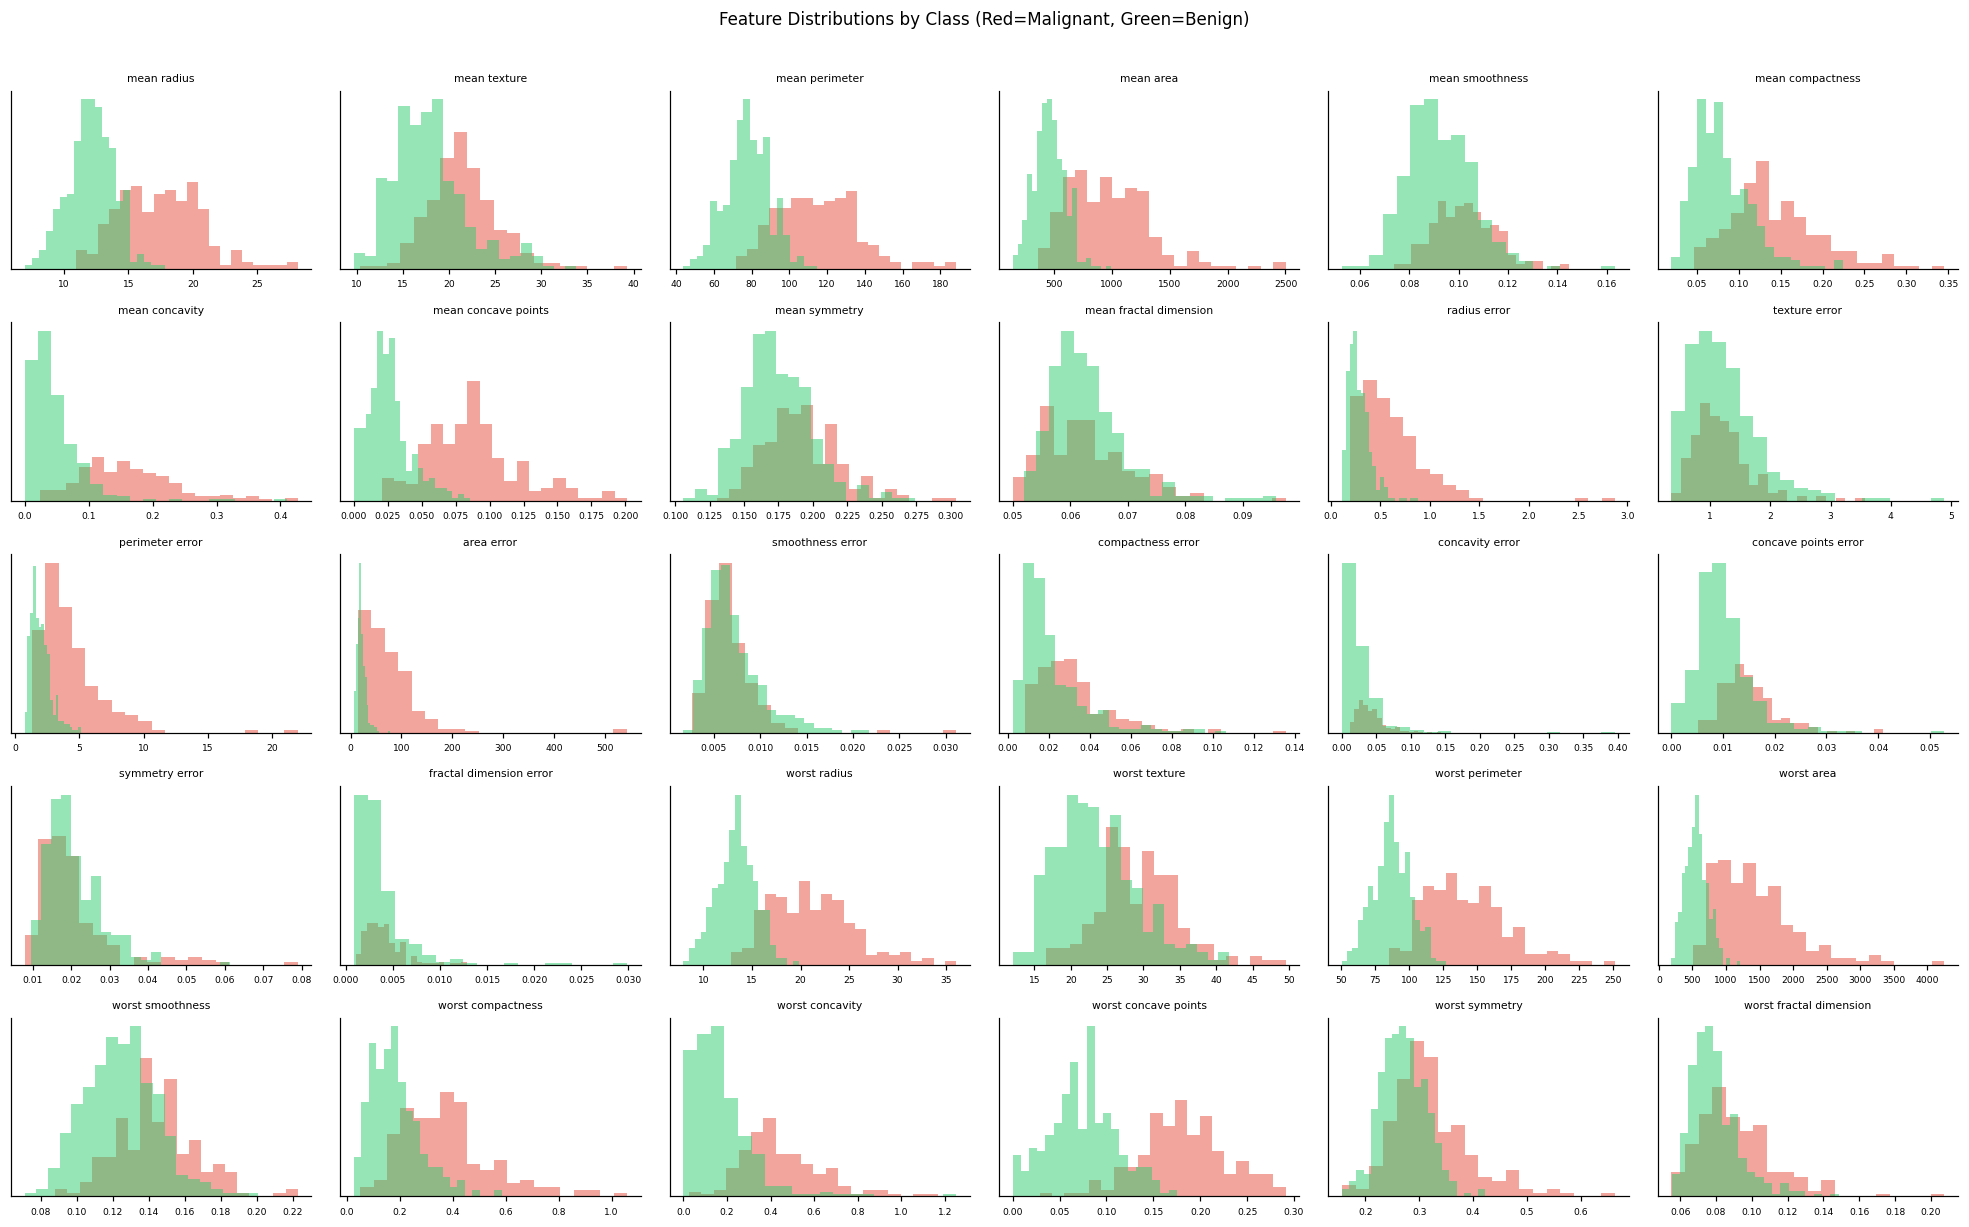

In [4]:
# Distribution of all features — look for skew and outliers
feat_cols = raw.feature_names.tolist()
n_cols = 6
n_rows = int(np.ceil(len(feat_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows*2.2))

for ax, col in zip(axes.ravel(), feat_cols):
    for label, color in zip([0,1],['#e74c3c','#2ecc71']):
        ax.hist(df[df['target']==label][col], bins=20,
                alpha=0.5, color=color, edgecolor='none')
    ax.set_title(col, fontsize=7)
    ax.tick_params(labelsize=6)
    ax.set_yticks([])

for ax in axes.ravel()[len(feat_cols):]:
    ax.axis('off')

plt.suptitle('Feature Distributions by Class (Red=Malignant, Green=Benign)', y=1.01, fontsize=11)
plt.tight_layout(); plt.show()


### 🤔 Reflection 2.1 — Distributions and Clinical Meaning

1. Some features (e.g., "worst area") have very long right tails. Name two ways this could
   cause problems for a linear model. How would you check whether this is hurting your model?

2. Several features are clearly bimodal — they separate the classes well visually.
   Does a large visual separation guarantee a model will perform well? What else matters?

3. In a real EHR, you might find a feature like "cholesterol = 0" that isn't a true zero
   but a missing value coded as 0 by the data entry system. How would you detect this?
   What would you do about it?

4. If a feature's distribution differs between malignant and benign cases, is that feature
   necessarily *causal*? Give an example where a feature is predictive but not causal,
   and explain why the distinction matters for clinical decision making.


---
### ✅ Solution — Reflection 2.1

**1.** Long right tails (right-skewed features) can cause two problems for linear models: (a) **outliers can have outsized influence** on the fitted coefficients, pulling the decision boundary toward extreme values; (b) **the linear assumption may be violated** — the relationship between the feature and the log-odds may not be linear across the full range. You could check this by comparing model performance with and without log-transforming (a widely used way to deal with **right-skewed** feature) skewed features, or by plotting residuals ($Y - \hat{Y}$) vs. fitted values.

**2.** No. Visual separation is necessary but not sufficient for good model performance. What also matters: (a) whether the separation holds in the *full feature space* (not just one feature at a time), (b) whether the separation generalizes to unseen data (not just training data), (c) how much overlap remains in the tails of the distributions, and (d) whether other features add noise that obscures the signal.

**3.** You could detect coded-as-zero missing values by: (a) checking if the distribution has an implausible spike at exactly 0 (e.g., cholesterol=0 is physiologically impossible), (b) checking if 0 values are far outside the expected clinical range, (c) consulting with clinicians about plausible value ranges. You should recode these as `NaN` and handle them with proper imputation rather than treating them as real measurements.

**4.** No — a feature can be **predictive without being causal**. For example, in this dataset, "worst symmetry" might correlate with malignancy, but asymmetry doesn't *cause* cancer — both could be downstream effects of rapid, uncontrolled cell growth. A clinical example: hospital admission date (weekday vs. weekend) may predict mortality (sicker patients are admitted on weekends), but the day of the week doesn't cause death. This matters because if you intervene on a non-causal predictive feature (e.g., rescheduling admissions), you won't change the outcome.


---
## Part 3 — Correlation and Multicollinearity

In the breast cancer dataset, radius, perimeter, and area are geometrically related:
perimeter ≈ 2πr, area ≈ πr². This means they carry almost the same information.

This is common in clinical data: BMI is derived from height and weight; eGFR is derived from
creatinine; many lab panels share underlying biological processes.

One way we can measure these relationships is to look at the [_correlation_](https://en.wikipedia.org/wiki/Correlation) between variables. Recall that the correlation between two random variables $X$ and $Y$ is given by:

$$
\rho_{X, Y} = \frac{\text{Cov}(X, Y)}{\sqrt{\text{Var}(X)\text{Var}(Y)}}
$$.

The code below measures and visualizes these correlations across all our features:

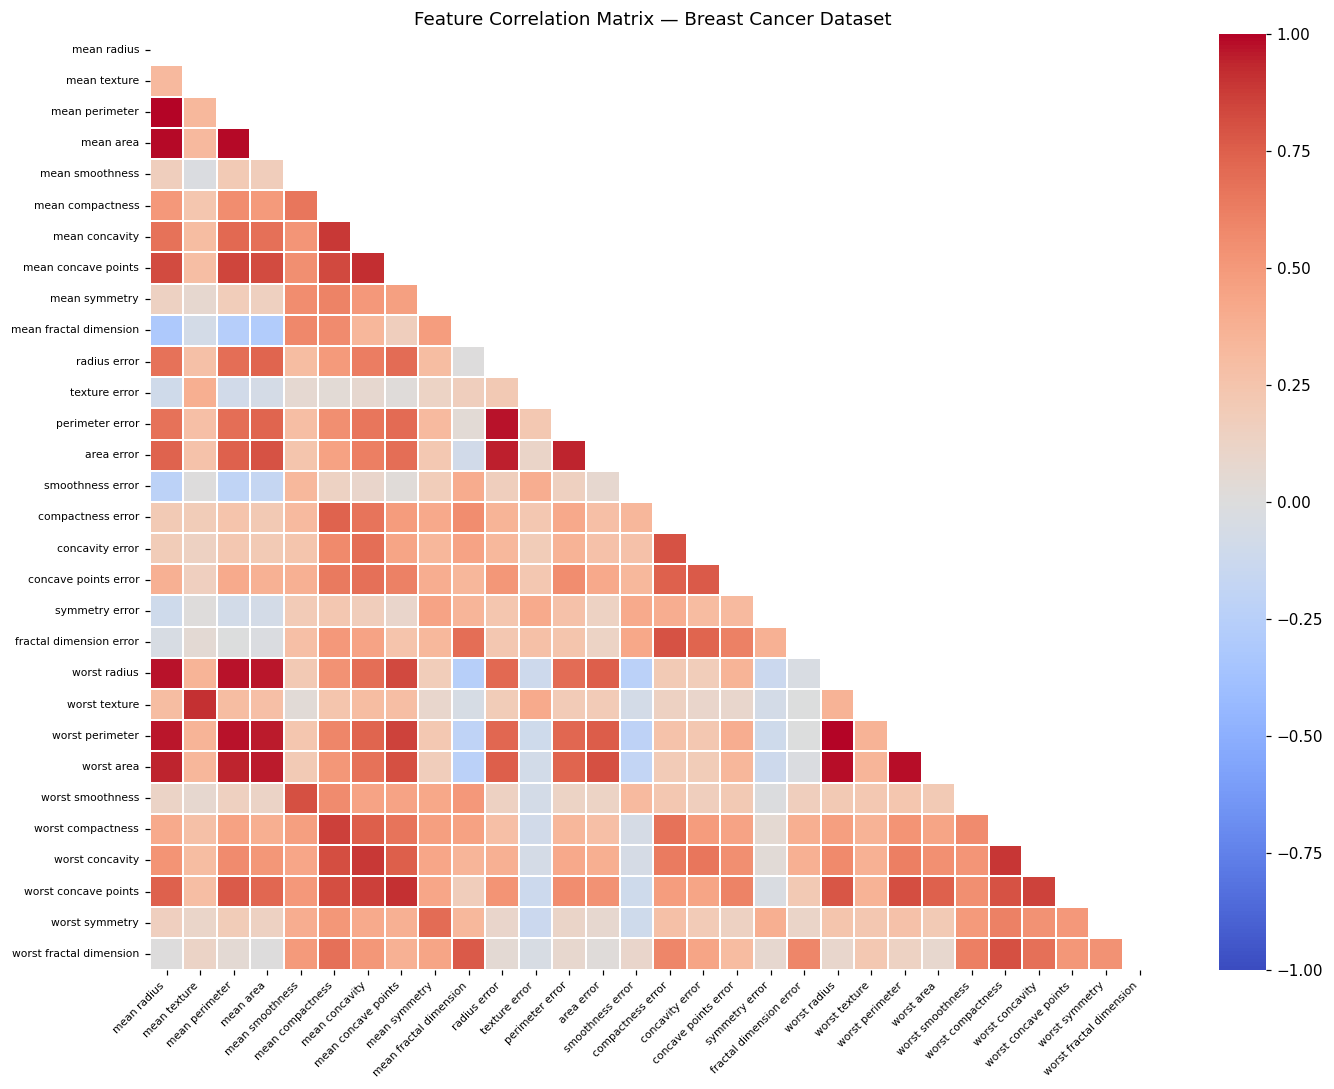

Feature pairs with |r| > 0.85: 29

Top 10 most correlated pairs:
      Feature 1       Feature 2        r
 mean perimeter     mean radius 0.997855
worst perimeter    worst radius 0.993708
      mean area     mean radius 0.987357
      mean area  mean perimeter 0.986507
     worst area    worst radius 0.984015
     worst area worst perimeter 0.977578
perimeter error    radius error 0.972794
worst perimeter  mean perimeter 0.970387
   worst radius     mean radius 0.969539
   worst radius  mean perimeter 0.969476


In [5]:
# Correlation heatmap
corr = df[feat_cols].corr()

plt.figure(figsize=(13, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0,
            vmin=-1, vmax=1, annot=False, linewidths=0.2,
            xticklabels=True, yticklabels=True)
plt.title('Feature Correlation Matrix — Breast Cancer Dataset', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.yticks(fontsize=7)
plt.tight_layout(); plt.show()

# Count highly correlated pairs
high_corr = (corr.abs() > 0.85) & (corr != 1.0)
n_high = high_corr.values.sum() // 2
print(f"Feature pairs with |r| > 0.85: {n_high}")
print("\nTop 10 most correlated pairs:")
pairs = [(corr.index[i], corr.columns[j], corr.iloc[i,j])
         for i in range(len(corr)) for j in range(i)
         if abs(corr.iloc[i,j]) > 0.85]
pairs_df = pd.DataFrame(pairs, columns=['Feature 1','Feature 2','r']).sort_values('r', ascending=False, key=abs)
print(pairs_df.head(10).to_string(index=False))


### 🤔 Reflection 3.1 — Why Multicollinearity Matters

1. If `mean radius` and `mean perimeter` have r = 0.998, how might this effect your modeling pipeline? Could it hurt your model's *predictive* performance? Could it hurt your model's *interpretability*? Explain your answer.

2. Name a common clinical dataset where you'd expect severe multicollinearity among lab values.

3. Suppose you wanted to keep only a subset of features. How might a clinician's intuition help you decide which features to keep?

4. Suppose you wanted your features to all not be correlated. How could you accomplish this? *Hint: How could you transform your input features to remove correlation?* What problems could this solve, and what problems could this create/worsen? Try and implement a version of this below.

5. Here, we have only measured *correlation*, which is only a measure of linear dependence. We have seen a different, more complete metric for dependency in our lectures on probability and information theory. What metric is that? Could you try to visualize those relationships as well? Why or why not? What would that tell you? What would happen if you tried to control for that metric in the same way you could correlation?

6. This examination only looks at _binary_ relationships (e.g., how is $X$ related to $Y$), and ignores higher-order relationships (e.g., how is $(X, Y)$ related to $Z$). Is it possible for there to be a higher order relationship without a binary relationship? Can you think of any clinical settings where such higher-order relationships may be present? Why do we often ignore these higher-order relationships in practice? Why does or does this not cause problems?

---
### ✅ Solution — Reflection 3.1

**1.** With r = 0.998, `mean radius` and `mean perimeter` carry nearly identical information. For *predictive* performance, this is usually not harmful — the model can use either feature. For *interpretability*, it is very harmful: the coefficients become **unstable and uninterpretable**. The model can assign arbitrary weights to two perfectly correlated features (e.g., +10 to radius and -10 to perimeter, or vice versa) and get the same predictions. Small changes in training data can flip coefficient signs entirely.

**2.** A comprehensive metabolic panel (CMP) has severe multicollinearity: BUN and creatinine are both markers of kidney function; AST and ALT are both liver enzymes; sodium, chloride, and CO₂ are linked through acid-base balance. The complete blood count (CBC) also has correlated components (e.g., hemoglobin and hematocrit).

**3.** A clinician could help by identifying which features are: (a) most clinically meaningful and actionable, (b) most reliably measured, (c) available at the point of care. For example, a clinician might prefer keeping `mean radius` over `mean perimeter` because radius is a more intuitive measurement, even though both carry the same information. Domain knowledge can break ties that statistical methods alone cannot.

**4.** **Principal Component Analysis (PCA)** transforms features into orthogonal (uncorrelated) principal components. You compute the eigenvectors of the covariance matrix and project the data onto them. This *solves* multicollinearity and can reduce dimensionality. However, it *creates/worsens* interpretability problems — PC1 is a linear combination of all original features and has no direct clinical meaning. It also assumes linear relationships and may discard small-variance components that are actually predictive.

**5.** **Mutual information** $I(X; Y)$ measures general (not just linear) dependence. Unlike correlation, it captures non-linear relationships. Visualizing mutual information for all pairs is possible (as a heatmap, analogous to the correlation matrix), but estimating MI from finite samples is harder than estimating correlation — it requires density estimation or binning. You *cannot* simply "decorrelate" features with respect to MI the way PCA removes linear correlation, because removing mutual information would require knowing the full joint distribution, which is generally intractable.

**6.** Yes — a higher-order relationship can exist without any pairwise relationship. The classic example is **XOR**: if $X$ and $Y$ are independent fair coin flips and $Z = X \oplus Y$, then $X$ and $Z$ are marginally independent, $Y$ and $Z$ are marginally independent, but $Z$ is completely determined by $(X, Y)$ jointly. In clinical settings, drug interactions are a natural example: Drug A alone has no effect, Drug B alone has no effect, but the combination is toxic. We often ignore higher-order relationships because (a) detecting them requires exponentially more data (the curse of dimensionality), (b) they are harder to interpret, and (c) in many settings, pairwise relationships capture most of the predictive signal. This can cause problems when interaction effects are strong, which is why some models (like trees and neural networks) can capture interactions automatically, while linear models cannot without explicit feature engineering.


---
## Part 4 — Simulating and Handling Missing Data

The breast cancer dataset has no missing values, but real clinical data almost always does.
We simulate realistic missingness to practice correct handling.

Vocabulary:
- MCAR = Missing Completely At Random
- MAR = Missing At Random
- MNAR = Missing Not At Random


Missing values introduced:
mean smoothness    28
mean concavity     66
dtype: int64


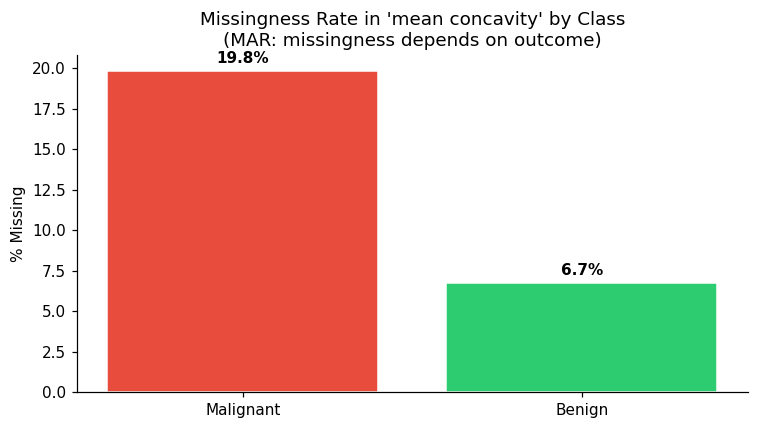

In [6]:
# Simulate missing data under two mechanisms
rng = np.random.default_rng(42)
df_missing = df[feat_cols + ['target']].copy()

# MCAR: Missing Completely At Random — random 5% dropout in 'mean smoothness'
idx_mcar = rng.choice(len(df_missing), size=int(0.05*len(df_missing)), replace=False)
df_missing.loc[idx_mcar, 'mean smoothness'] = np.nan

# MAR: Missing At Random — malignant cases 3x more likely to have missing 'mean concavity'
mal_idx = df_missing[df_missing['target']==0].index
miss_mal = rng.choice(mal_idx, size=int(0.20*len(mal_idx)), replace=False)
ben_idx  = df_missing[df_missing['target']==1].index
miss_ben = rng.choice(ben_idx,  size=int(0.07*len(ben_idx)),  replace=False)
df_missing.loc[np.concatenate([miss_mal, miss_ben]), 'mean concavity'] = np.nan

print("Missing values introduced:")
print(df_missing.isnull().sum()[df_missing.isnull().sum()>0])

# Visualize: is the missingness of 'mean concavity' related to class?
fig, ax = plt.subplots(figsize=(7,4))
for label, color, name in zip([0,1],['#e74c3c','#2ecc71'],['Malignant','Benign']):
    subset = df_missing[df_missing['target']==label]
    miss_rate = subset['mean concavity'].isna().mean()
    ax.bar(name, miss_rate*100, color=color, edgecolor='white')
    ax.text(name, miss_rate*100+0.5, f'{miss_rate:.1%}', ha='center', fontweight='bold')
ax.set_ylabel('% Missing'); ax.set_title("Missingness Rate in 'mean concavity' by Class\n(MAR: missingness depends on outcome)")
plt.tight_layout(); plt.show()


### 🤔 Reflection 4.1 — Missing Data Mechanisms

1. **MCAR vs MAR vs MNAR**: We simulated MCAR (mean smoothness) and MAR (mean concavity).
   Describe what "Missing Not at Random" (MNAR) would look like in a clinical setting.
   Give a concrete example involving blood pressure measurements.

2. For the `mean concavity` feature (MAR), malignant cases are 3× more likely to have
   missing values. If you simply drop rows with missing values, what bias does this
   introduce into your training set? Which class becomes under-represented?

3. We're about to use mean imputation. Under what distributional assumption is
   mean imputation "correct"? Does that assumption hold here?

4. Why is it critical to fit the imputer **only on training data** and then apply it to
   validation/test data? What specific number would "leak" if you fit on all data?


---
### ✅ Solution — Reflection 4.1

**1.** **MNAR** means the probability of a value being missing depends on the *unobserved value itself*. Blood pressure example: patients with very high blood pressure may feel dizzy and leave the clinic before their reading is recorded, or a nurse might re-measure and discard a reading that seems "too high" (thinking it's an error). In both cases, the missingness depends on the (unobserved) true blood pressure value. MNAR is the hardest mechanism to handle because the missing data pattern is informative about the missing values themselves.

**2.** Since malignant cases are 3× more likely to have `mean concavity` missing, dropping rows with missing values disproportionately removes **malignant** cases. This makes the malignant class under-represented in the training set, biasing the model toward predicting benign. The model would have lower sensitivity (more missed cancers) because it was trained on a dataset where malignant cases were systematically removed.

**3.** Mean imputation is "correct" (in the sense of preserving the marginal mean) when the data is MCAR and the feature is approximately normally distributed with no relationship to other features. Here, the missingness of `mean concavity` is MAR (depends on class), so mean imputation fills in values that don't reflect the actual distribution within each class. For malignant cases, the imputed mean (computed from mostly benign training data) will systematically underestimate the true concavity values.

**4.** If you fit the imputer on all data (including validation/test), the **imputed mean** for `mean concavity` would incorporate information from validation and test patients. The specific "leaked" number is the feature mean: `np.mean(all_data[:, concavity_col])` vs. the correct `np.mean(train_data[:, concavity_col])`. These will differ because the val/test sets have different class compositions. This is data leakage — the model indirectly sees test-set information through the imputed values.


In [7]:
# Compare imputation strategies
from sklearn.impute import SimpleImputer, KNNImputer

strategies = {
    'Mean imputation': SimpleImputer(strategy='mean'),
    'Median imputation': SimpleImputer(strategy='median'),
    'KNN imputation (k=5)': KNNImputer(n_neighbors=5),
}

# Use only training data to fit imputers (correct approach)
# We'll do a quick train/val split of df_missing for demonstration
from sklearn.model_selection import train_test_split
X_m = df_missing[feat_cols].values
y_m = df_missing['target'].values
Xm_tr, Xm_val, _, _ = train_test_split(X_m, y_m, test_size=0.3, random_state=42)

col_idx_concavity = feat_cols.index('mean concavity')
print(f"'mean concavity' — column index: {col_idx_concavity}")
print(f"True train mean (non-missing): {np.nanmean(Xm_tr[:, col_idx_concavity]):.4f}")
print()

for name, imp in strategies.items():
    imp.fit(Xm_tr)                     # ← fit on train only
    Xm_tr_imp = imp.transform(Xm_tr)
    Xm_val_imp = imp.transform(Xm_val) # ← apply to val
    remaining_miss = np.isnan(Xm_val_imp).sum()
    imp_val = np.nanmean(Xm_val_imp[:, col_idx_concavity])
    print(f"{name}: imputed val mean = {imp_val:.4f},  remaining missing = {remaining_miss}")

print("\n⚠️  Wrong approach (data leakage): fitting imputer on ALL data before splitting")
leaky_imp = SimpleImputer(strategy='mean')
leaky_imp.fit(X_m)   # fits on val/test too!
print(f"Leaky imputed mean = {leaky_imp.statistics_[col_idx_concavity]:.4f}  (uses test info)")


'mean concavity' — column index: 6
True train mean (non-missing): 0.0829

Mean imputation: imputed val mean = 0.0852,  remaining missing = 0
Median imputation: imputed val mean = 0.0821,  remaining missing = 0
KNN imputation (k=5): imputed val mean = 0.0897,  remaining missing = 0

⚠️  Wrong approach (data leakage): fitting imputer on ALL data before splitting
Leaky imputed mean = 0.0837  (uses test info)


---
## Part 5 — Feature Scaling

Many algorithms assume features are on comparable scales. Without scaling, a feature
measured in thousands (e.g., area in µm²) will dominate one measured in fractions (e.g., smoothness).


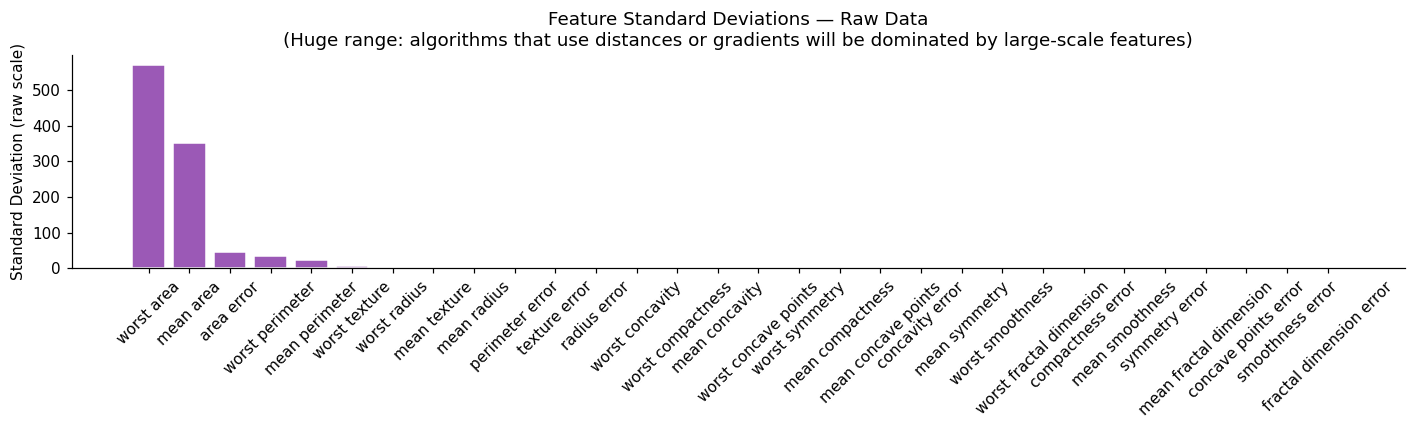

Largest std: worst area  = 569.4
Smallest std: fractal dimension error = 0.0026
Ratio: 215171x difference in scale


In [8]:
# Show scale differences across features
scales = df[feat_cols].std().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(scales.index, scales.values, color='#9b59b6', edgecolor='white')
ax.set_ylabel('Standard Deviation (raw scale)')
ax.set_title('Feature Standard Deviations — Raw Data\n(Huge range: algorithms that use distances or gradients will be dominated by large-scale features)')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

print(f"Largest std: {scales.index[0]}  = {scales.iloc[0]:.1f}")
print(f"Smallest std: {scales.index[-1]} = {scales.iloc[-1]:.4f}")
print(f"Ratio: {scales.iloc[0]/scales.iloc[-1]:.0f}x difference in scale")


### 🤔 Reflection 5.1 — When Does Scaling Matter?

Below, we ask about some different types of models. These will also be explored more deeply in the model-specific notebooks.

1. **Logistic regression**: Would the *predictions* of a logistic regression change if you
   forgot to scale? Would the *coefficients* change? Explain why or why not.
   (Hint: think about what happens to the weights when features have very different scales.)

2. **k-Nearest Neighbors**: Explain concretely why scaling is absolutely critical for KNN.
   Give an example using two features — one in millimeters and one in kilograms — and
   describe what would happen to the "nearest neighbor" calculation without scaling.

3. **Decision trees**: Why are decision trees invariant to monotonic transformations of
   features (including scaling)?

4. **Neural Networks**: Suppose we are training a neural network with stochastic gradient descent. What impact does feature scale have on the gradients computed for a loss in this setting? _Hint: Try examining the gradient of the weights of a linear layer with respect to a 1D output._

5. **Train-only fitting**: We fit the scaler on training data and apply it to test data.
   What specific numbers would be "contaminated" if we fit on all data? Write out
   the StandardScaler formula and identify which terms would be wrong.


---
### ✅ Solution — Reflection 5.1

**1. Logistic regression:** The *predictions* would **not change** (assuming the optimizer converges to the same optimum) — the model can compensate for different feature scales by adjusting its weights. However, the *coefficients* would change dramatically. A feature measured in thousands would get a tiny weight; a feature measured in fractions would get a huge weight. This makes coefficients incomparable across features and interpretation as "importance" misleading. In practice, convergence can also be slower without scaling due to elongated loss contours.

**2. k-Nearest Neighbors:** Scaling is critical because KNN computes distances: $d(a,b) = \sqrt{\sum_j (a_j - b_j)^2}$. If feature 1 is height in mm (range ~1500–2000) and feature 2 is weight in kg (range ~50–120), then height contributes up to $(500)^2 = 250,000$ to the distance while weight contributes at most $(70)^2 = 4,900$. Height completely dominates the "nearest neighbor" calculation, and weight is effectively ignored. Two patients with identical heights but very different weights would be considered "nearest neighbors."

**3. Decision trees:** Trees split on thresholds: "is feature $j > t$?" If you apply any monotonic transformation $g$ to feature $j$, the split "is $g(x_j) > g(t)$?" produces exactly the same partition of the data. The ordering of samples along each feature axis is preserved, so the same splits are chosen. This is why trees don't need scaling.

**4. Neural networks:** Consider a linear layer $z = w^T x + b$. The gradient with respect to $w_j$ is $\frac{\partial L}{\partial w_j} = \frac{\partial L}{\partial z} \cdot x_j$. If $x_j$ has a large scale (e.g., range 0–1000), the gradient for $w_j$ will be ~1000× larger than for a feature with range 0–1. This means SGD takes huge steps for large-scale features and tiny steps for small-scale ones, making optimization inefficient — the loss landscape has highly elongated contours, and a single learning rate cannot work well for all weights simultaneously.

**5.** StandardScaler computes $x_{\text{scaled}} = (x - \mu) / \sigma$ where $\mu$ and $\sigma$ are the mean and standard deviation. If fit on all data, $\mu$ and $\sigma$ would incorporate val/test samples. The contaminated values are specifically: $\mu_{\text{all}} \neq \mu_{\text{train}}$ and $\sigma_{\text{all}} \neq \sigma_{\text{train}}$. When applied to test data, the scaled values would be shifted and stretched relative to what the model expects, and the model would have been trained on slightly "centered" data that benefited from knowing the test distribution.


Full splits — Train: 341  Val: 114  Test: 114


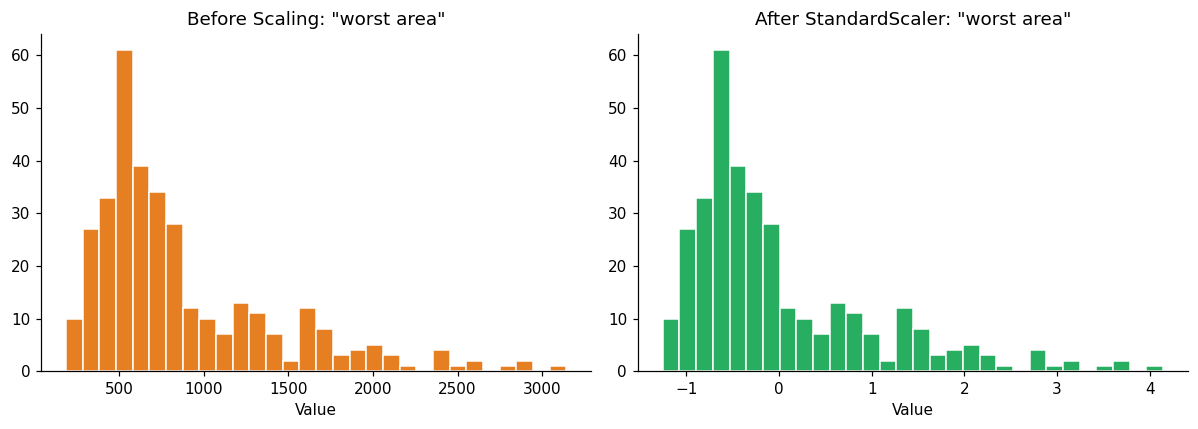

Before: mean=872.1, std=548.0
After:  mean=-0.0000, std=1.0000


In [9]:
# Train / Val / Test split first (stratified)
X_full = df[feat_cols].values
y_full = df['target'].values

X_train_f, X_tmp, y_train_f, y_tmp = train_test_split(
    X_full, y_full, test_size=0.40, random_state=42, stratify=y_full)
X_val_f, X_test_f, y_val_f, y_test_f = train_test_split(
    X_tmp, y_tmp, test_size=0.50, random_state=42, stratify=y_tmp)

print(f"Full splits — Train: {X_train_f.shape[0]}  Val: {X_val_f.shape[0]}  Test: {X_test_f.shape[0]}")

# Fit scaler on training data only
scaler_full = StandardScaler()
X_train_fs = scaler_full.fit_transform(X_train_f)
X_val_fs   = scaler_full.transform(X_val_f)
X_test_fs  = scaler_full.transform(X_test_f)

# Show before / after for worst area (largest range)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
col_wa = feat_cols.index('worst area')
for ax, data, title, color in zip(
    axes,
    [X_train_f[:,col_wa], X_train_fs[:,col_wa]],
    ['Before Scaling: "worst area"', 'After StandardScaler: "worst area"'],
    ['#e67e22','#27ae60']
):
    ax.hist(data, bins=30, color=color, edgecolor='white')
    ax.set_title(title)
    ax.set_xlabel('Value')
plt.tight_layout(); plt.show()
print(f"Before: mean={X_train_f[:,col_wa].mean():.1f}, std={X_train_f[:,col_wa].std():.1f}")
print(f"After:  mean={X_train_fs[:,col_wa].mean():.4f}, std={X_train_fs[:,col_wa].std():.4f}")


---
## Part 6 — Feature Selection and Creating a Realistic "Hard" Dataset

The full dataset with all 30 features gives AUC > 0.99 on real models — not realistic for most clinical problems. We'll create a restricted dataset by:
1. Removing the most informative features (simulating limited data collection)
2. Sub-sampling the training set (simulating small study sizes)

This creates a more realistic setting where model choice and preprocessing decisions actually matter. In practice, of course, you wouldn't do this, but for these notebooks, it will help make things easier.


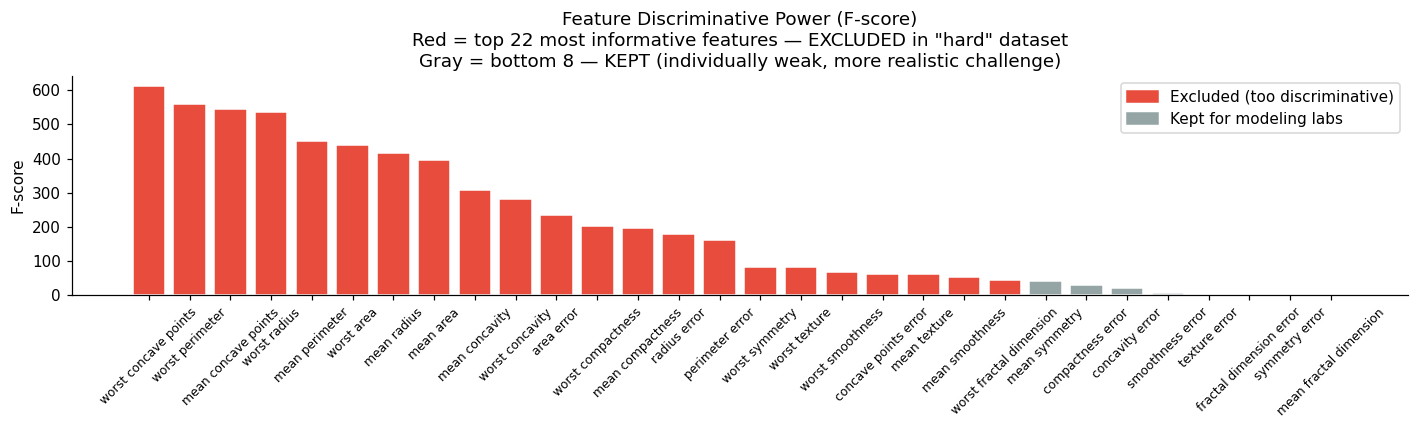

Bottom 8 features (kept for modeling labs):
['mean symmetry', 'compactness error', 'concavity error', 'smoothness error', 'texture error', 'fractal dimension error', 'symmetry error', 'mean fractal dimension']


In [10]:
from sklearn.feature_selection import f_classif

# Rank features by univariate F-score on the full training set
f_scores, _ = f_classif(X_train_fs, y_train_f)
f_series = pd.Series(f_scores, index=feat_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(13, 4))
colors = ['#e74c3c' if i < 22 else '#95a5a6' for i in range(len(f_series))]
ax.bar(f_series.index, f_series.values, color=colors, edgecolor='white')
ax.set_ylabel('F-score')
ax.set_title('Feature Discriminative Power (F-score)\n'
             'Red = top 22 most informative features — EXCLUDED in "hard" dataset\n'
             'Gray = bottom 8 — KEPT (individually weak, more realistic challenge)')
ax.tick_params(axis='x', rotation=45, labelsize=8)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#e74c3c', label='Excluded (too discriminative)'),
                   Patch(color='#95a5a6', label='Kept for modeling labs')], loc='upper right')
plt.tight_layout(); plt.show()

print(f"Bottom 8 features (kept for modeling labs):")
print(f_series.index[22:].tolist())


In [11]:
# Build "hard" splits:
#   - Keep only the BOTTOM 8 features by F-score (least individually informative)
#   - Sub-sample training to 100 examples (realistic small clinical study)
# This gives AUC ~0.83–0.86 — realistic for a constrained clinical dataset.

hard_features = f_series.index[22:].tolist()   # bottom 8 by F-score
hard_col_idx  = [feat_cols.index(c) for c in hard_features]

X_train_h = X_train_fs[:, hard_col_idx]
X_val_h   = X_val_fs[:, hard_col_idx]
X_test_h  = X_test_fs[:, hard_col_idx]

# Sub-sample training to 100 examples
rng2 = np.random.default_rng(42)
n_hard_train = 100
hard_idx = rng2.choice(len(X_train_h), size=n_hard_train, replace=False)
X_train_hard = X_train_h[hard_idx]
y_train_hard = y_train_f[hard_idx]

X_val_hard  = X_val_h
y_val_hard  = y_val_f
X_test_hard = X_test_h
y_test_hard = y_test_f

print(f"Hard training set: {X_train_hard.shape}")
print(f"Hard val set:      {X_val_hard.shape}")
print(f"Hard test set:     {X_test_hard.shape}")
print(f"Training prevalence: {y_train_hard.mean():.2%} benign")
print(f"Features kept: {hard_features}")

# Quick sanity: what AUC does a simple model achieve?
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
lr_sanity = LogisticRegression(C=1.0, max_iter=500, random_state=42)
lr_sanity.fit(X_train_hard, y_train_hard)
auc_sanity = roc_auc_score(y_val_hard, lr_sanity.predict_proba(X_val_hard)[:,1])
print(f"\nLogistic regression AUC on hard val set: {auc_sanity:.3f}  (target: 0.80 – 0.90)")


Hard training set: (100, 8)
Hard val set:      (114, 8)
Hard test set:     (114, 8)
Training prevalence: 60.00% benign
Features kept: ['mean symmetry', 'compactness error', 'concavity error', 'smoothness error', 'texture error', 'fractal dimension error', 'symmetry error', 'mean fractal dimension']

Logistic regression AUC on hard val set: 0.839  (target: 0.80 – 0.90)


### 🤔 Reflection 6.1 — What Makes a Problem Hard?

1. We removed the top-10 most informative features. In a real clinical study, why might
   you not have access to the most informative biomarkers? Give two examples
   (one from cost, one from timing).

2. We sub-sampled the training set to 100 examples. What are the statistical consequences
   of a small training set? How does this interact with model complexity (number of parameters)?

3. With 100 training samples and 8 features, are you at risk of overfitting even with
   a simple logistic regression? How many parameters does logistic regression have here?

4. In practice, should you always use all available features? Describe a scenario where
   adding more features *hurts* generalization performance.


---
### ✅ Solution — Reflection 6.1

**1.** In real clinical studies, you often lack the most informative biomarkers because: **(Cost)** Advanced biomarkers like whole-genome sequencing, specialized imaging (PET scans), or liquid biopsy panels can cost thousands of dollars per patient, making them infeasible for routine screening. **(Timing)** Some tests take days or weeks (e.g., culture results, genetic testing), but clinical decisions may need to be made in hours. A triage model must work with the features available at the point of care.

**2.** With a small training set, parameter estimates have high variance — the model is very sensitive to which particular patients happen to be in the training set. Confidence intervals on predictions are wide. This interacts with model complexity: a model with many parameters relative to the sample size can easily memorize the training data (overfitting). The effective number of degrees of freedom should be much smaller than $n$ for reliable generalization.

**3.** With 100 training samples and 8 features, logistic regression has $8 + 1 = 9$ parameters. The ratio is ~11 samples per parameter, which is borderline — a common rule of thumb suggests 10–20 events per variable for logistic regression. You are at some risk of overfitting, especially if features are correlated (effective dimensionality is lower than 8, but multicollinearity inflates coefficient variance).

**4.** No — adding more features can hurt generalization when: (a) the new features are noisy or irrelevant, diluting the signal (especially harmful for distance-based methods like KNN); (b) the sample size is too small to reliably estimate the additional parameters (curse of dimensionality); (c) correlated features introduce multicollinearity. Example: adding 50 random gene expression features to a model that already has 8 strong clinical features could cause overfitting and degrade test performance, even though the model has "more information."


---
## Part 7 — Save Processed Data

All subsequent model labs will load this file.


In [12]:
processed = {
    # Full splits (all features, full training size)
    'X_train': X_train_fs, 'y_train': y_train_f,
    'X_val':   X_val_fs,   'y_val':   y_val_f,
    'X_test':  X_test_fs,  'y_test':  y_test_f,
    'feature_names': feat_cols,
    # Hard splits (restricted features, sub-sampled training)
    'X_train_hard': X_train_hard, 'y_train_hard': y_train_hard,
    'X_val_hard':   X_val_hard,   'y_val_hard':   y_val_hard,
    'X_test_hard':  X_test_hard,  'y_test_hard':  y_test_hard,
    'feature_names_hard': hard_features,
    # Metadata
    'scaler': scaler_full,
    'class_names': raw.target_names.tolist(),
    'hard_col_idx': hard_col_idx,
}

with open('processed_data.pkl', 'wb') as f:
    pickle.dump(processed, f)

print("✅ Saved processed_data.pkl")
print(f"   Keys: {list(processed.keys())}")


✅ Saved processed_data.pkl
   Keys: ['X_train', 'y_train', 'X_val', 'y_val', 'X_test', 'y_test', 'feature_names', 'X_train_hard', 'y_train_hard', 'X_val_hard', 'y_val_hard', 'X_test_hard', 'y_test_hard', 'feature_names_hard', 'scaler', 'class_names', 'hard_col_idx']


---
## 🧠 Final Reflection — The Preprocessing Pipeline as a Whole

Answer all of these before moving to the model labs:

1. **Order of operations**: Why must you (a) split first, (b) then fit imputer/scaler on
   train, (c) then transform val/test? Draw the pipeline as a diagram and mark where
   data leakage could occur at each step.

2. **Clinical deployment**: Your preprocessing pipeline includes a scaler fitted on your
   training data. When you deploy this model at a new hospital six months later, what
   do you need to deploy alongside the model weights? What happens if you forget?

3. **Distribution shift**: The new hospital's patient population has different demographics
   than your training set. Which steps of your preprocessing pipeline are most sensitive
   to this shift? What would you monitor in production?

4. **Reproducibility crisis**: A published paper reports 0.98 AUC on a breast cancer dataset.
   Name three preprocessing mistakes (beyond the ones covered in this lab) that could
   cause this number to be inflated. How would you audit the paper?


---
### ✅ Solution — Final Reflection

**1. Order of operations:**

```
Raw Data → [SPLIT into Train / Val / Test]
                    ↓
              Train set only
                    ↓
           [FIT imputer on train] → [TRANSFORM train, val, test]
                    ↓
           [FIT scaler on train]  → [TRANSFORM train, val, test]
                    ↓
           [Train model on train] → [Evaluate on val] → [Final eval on test]
```

Data leakage points: (a) If you scale/impute before splitting, the scaler/imputer learns statistics from val/test data. (b) If you fit the scaler on all data after splitting, the mean/std are contaminated. (c) If you do feature selection using all data, the selected features reflect val/test patterns.

**2.** You must deploy the **fitted scaler** (with its stored mean and std), the **fitted imputer** (with its stored fill values), and any feature selection indices — not just the model weights. If you forget the scaler, raw feature values will be on the wrong scale, and predictions will be meaningless. The preprocessing pipeline is part of the model.

**3.** The **scaler** (mean/std) is most sensitive to distribution shift — if the new hospital's patients have different demographics (age, ethnicity, disease severity), feature distributions will differ. The **imputer** is also sensitive if missingness patterns differ. In production, you should monitor: (a) feature distributions (comparing incoming data to training data), (b) prediction distributions (calibration drift), (c) missingness rates, and (d) outcome data when available (to detect performance degradation).

**4.** Three preprocessing mistakes that inflate AUC: (a) **Feature selection on the full dataset** before splitting — the selected features are optimized for the test set. (b) **Duplicate patients** across train and test sets — if the same patient appears in both (common in EHR data with multiple visits), test performance reflects memorization. (c) **Temporal leakage** — using future information to predict past outcomes (e.g., including a lab result that was ordered *because* the diagnosis was already suspected). To audit: request the code/pipeline, check the split procedure, verify no leakage in feature engineering, and attempt to reproduce on a held-out external dataset.
